# Verfahrenswahrscheinlichkeit im (p,h)-Diagramm

Unter dem Binomialmodell $X\sim B(n,p_0)$ werden wiederholt Stichproben erzeugt. Jede Realisation der relativen Häufigkeit $H=X/n$ erscheint als Punkt auf der senkrechten Linie $p=p_0$. Gleiche Werte werden nur für die Darstellung nach rechts gestapelt.

Die Randkurven

$$
h=p\pm z\sqrt{\frac{p(1-p)}{n}}
$$

begrenzen den normalapproximativen Neyman-Raum. Offen dargestellte Punkte liegen im Prognoseintervall zum festgelegten Parameter $p_0$; grau gefüllte Punkte liegen außerhalb.

> **Modellhinweis:** Die Einordnung der Punkte und sämtliche Wahrscheinlichkeitsaussagen beziehen sich auf das festgelegte Binomialmodell.

## Eingaben

Nur die folgende Zelle muss verändert werden.

- `n`: Stichprobenumfang
- `number_of_samples`: Anzahl der simulierten Stichproben
- `p0`: Parameter des Binomialmodells
- `gamma`: Zielniveau
- `seed`: Startwert des Zufallszahlengenerators
- `save_figure`: `True` oder `False`

Die weiteren Eingaben steuern Ausschnitt, Stapelung, Beschriftung, Anzeige und Dateiausgabe.

In [21]:
from __future__ import annotations

from collections import Counter
from dataclasses import dataclass
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
import numpy as np
from scipy.stats import binom, norm


@dataclass(frozen=True)
class Config:
    # Mathematische Eingaben
    n: int = 400
    number_of_samples: int = 100
    p0: float = 0.15
    gamma: float = 0.90
    seed: int = 7

    # Dargestellter Bereich und Stapelung
    p_min: float = 0.0
    p_max: float = 0.25
    h_min: float = 0.0
    h_max: float = 0.25
    number_of_curve_points: int = 2001
    stack_step: float = 0.005

    # Beschriftung der Grafik
    show_title: bool = True
    show_subtitle: bool = True

    # Ausgabe des Notebooks
    show_text_output: bool = True
    show_figure: bool = True
    save_figure: bool = True
    save_formats: tuple[str, ...] = ("png", "pdf")
    output_dir: str = "fig"
    png_dpi: int = 240


cfg = Config()

## Prüfung und mathematische Berechnung

Berechnung und Darstellung sind getrennt. Zunächst werden die Eingaben geprüft und die Stichproben erzeugt. Anschließend werden gleiche Trefferzahlen gezählt und die zugehörigen Punkte ausschließlich nach rechts von $p_0$ gestapelt.

Zusätzlich zur empirischen Verfahrenswahrscheinlichkeit der Simulation wird die zugehörige Modellwahrscheinlichkeit exakt als Binomialsumme berechnet.

In [22]:
@dataclass(frozen=True)
class Calculation:
    z: float
    p: np.ndarray
    lower: np.ndarray
    upper: np.ndarray
    x_values: np.ndarray
    h_values: np.ndarray
    p_points: np.ndarray
    h_points: np.ndarray
    inside: np.ndarray
    prediction_lower_at_p0: float
    prediction_upper_at_p0: float
    accepted_x: np.ndarray
    model_coverage: float
    empirical_coverage: float


def validate_config(cfg: Config) -> None:
    if not isinstance(cfg.n, int) or isinstance(cfg.n, bool) or cfg.n <= 0:
        raise ValueError("n muss eine positive ganze Zahl sein.")
    if (
        not isinstance(cfg.number_of_samples, int)
        or isinstance(cfg.number_of_samples, bool)
        or cfg.number_of_samples <= 0
    ):
        raise ValueError("number_of_samples muss eine positive ganze Zahl sein.")
    if not 0.0 <= cfg.p0 <= 1.0:
        raise ValueError("p0 muss zwischen 0 und 1 liegen.")
    if not 0.0 < cfg.gamma < 1.0:
        raise ValueError("gamma muss zwischen 0 und 1 liegen.")
    if not isinstance(cfg.seed, int) or isinstance(cfg.seed, bool):
        raise ValueError("seed muss eine ganze Zahl sein.")
    if not 0.0 <= cfg.p_min < cfg.p_max <= 1.0:
        raise ValueError("Für den p-Bereich muss 0 <= p_min < p_max <= 1 gelten.")
    if not 0.0 <= cfg.h_min < cfg.h_max <= 1.0:
        raise ValueError("Für den h-Bereich muss 0 <= h_min < h_max <= 1 gelten.")
    if not cfg.p_min <= cfg.p0 <= cfg.p_max:
        raise ValueError("p0 muss im dargestellten p-Bereich liegen.")
    if cfg.number_of_curve_points < 101:
        raise ValueError("number_of_curve_points muss mindestens 101 sein.")
    if cfg.stack_step <= 0.0:
        raise ValueError("stack_step muss positiv sein.")
    if cfg.png_dpi <= 0:
        raise ValueError("png_dpi muss positiv sein.")
    if not cfg.output_dir.strip():
        raise ValueError("output_dir darf nicht leer sein.")

    formats = {fmt.lower().lstrip(".") for fmt in cfg.save_formats}
    unsupported = formats - {"png", "pdf"}
    if unsupported:
        names = ", ".join(sorted(unsupported))
        raise ValueError(f"Nicht unterstützte Speicherformate: {names}")


def prediction_bounds(
    p: np.ndarray,
    *,
    n: int,
    z: float,
) -> tuple[np.ndarray, np.ndarray]:
    radius = z * np.sqrt(p * (1.0 - p) / n)
    return p - radius, p + radius


def stack_to_the_right(
    x_values: np.ndarray,
    *,
    n: int,
    p0: float,
    stack_step: float,
) -> tuple[np.ndarray, np.ndarray]:
    p_points: list[float] = []
    h_points: list[float] = []

    for x_value, multiplicity in sorted(Counter(x_values).items()):
        p_points.extend(p0 + stack_step * np.arange(multiplicity))
        h_points.extend([x_value / n] * multiplicity)

    return np.asarray(p_points), np.asarray(h_points)


def calculate(cfg: Config) -> Calculation:
    validate_config(cfg)

    z = norm.ppf((1.0 + cfg.gamma) / 2.0)
    p = np.linspace(0.0, 1.0, cfg.number_of_curve_points)
    lower, upper = prediction_bounds(p, n=cfg.n, z=z)

    rng = np.random.default_rng(cfg.seed)
    x_values = rng.binomial(cfg.n, cfg.p0, size=cfg.number_of_samples)
    h_values = x_values / cfg.n
    p_points, h_points = stack_to_the_right(
        x_values,
        n=cfg.n,
        p0=cfg.p0,
        stack_step=cfg.stack_step,
    )

    if p_points.max() > cfg.p_max:
        raise ValueError(
            "Die gestapelten Punkte reichen über p_max hinaus. "
            "p_max vergrößern oder stack_step verkleinern."
        )

    radius0 = z * np.sqrt(cfg.p0 * (1.0 - cfg.p0) / cfg.n)
    prediction_lower_at_p0 = cfg.p0 - radius0
    prediction_upper_at_p0 = cfg.p0 + radius0
    inside = (
        (h_points >= prediction_lower_at_p0)
        & (h_points <= prediction_upper_at_p0)
    )

    x_support = np.arange(cfg.n + 1)
    h_support = x_support / cfg.n
    accepted = (
        (h_support >= prediction_lower_at_p0)
        & (h_support <= prediction_upper_at_p0)
    )
    accepted_x = x_support[accepted]
    model_coverage = float(binom.pmf(accepted_x, cfg.n, cfg.p0).sum())

    return Calculation(
        z=z,
        p=p,
        lower=lower,
        upper=upper,
        x_values=x_values,
        h_values=h_values,
        p_points=p_points,
        h_points=h_points,
        inside=inside,
        prediction_lower_at_p0=prediction_lower_at_p0,
        prediction_upper_at_p0=prediction_upper_at_p0,
        accepted_x=accepted_x,
        model_coverage=model_coverage,
        empirical_coverage=float(inside.mean()),
    )

## Grafik

Die Grafik ist vollständig in Graustufen angelegt. Die Füllung unterscheidet die beiden Punktarten auch unabhängig vom Farbton: offen bedeutet innerhalb, grau gefüllt bedeutet außerhalb des Prognoseintervalls. Titel und Untertitel lassen sich getrennt ein- und ausschalten.

In [23]:
def german_tick(value: float, _position: float) -> str:
    if abs(value) < 5e-12:
        value = 0.0
    return f"{value:g}".replace(".", ",")


def math_decimal(value: float, decimals: int) -> str:
    return f"{value:.{decimals}f}".replace(".", "{,}")


def create_figure(
    cfg: Config,
    calculation: Calculation,
) -> tuple[plt.Figure, plt.Axes]:
    fig, ax = plt.subplots(figsize=(6.4, 6.4))

    ax.plot(
        calculation.p,
        calculation.lower,
        color="0.25",
        linewidth=1.2,
        zorder=1,
    )
    ax.plot(
        calculation.p,
        calculation.upper,
        color="0.25",
        linewidth=1.2,
        zorder=1,
    )
    ax.axvline(
        cfg.p0,
        color="0.70",
        linestyle="--",
        linewidth=1.2,
        zorder=1,
    )

    ax.scatter(
        calculation.p_points[calculation.inside],
        calculation.h_points[calculation.inside],
        s=20,
        facecolors="white",
        edgecolors="black",
        linewidths=1.0,
        zorder=3,
    )
    ax.scatter(
        calculation.p_points[~calculation.inside],
        calculation.h_points[~calculation.inside],
        s=26,
        facecolors="tab:red",
        edgecolors="black",
        linewidths=1.0,
        zorder=4,
    )

    ax.set_xlim(cfg.p_min, cfg.p_max)
    ax.set_ylim(cfg.h_min, cfg.h_max)
    ax.set_aspect("equal", adjustable="box")
    ax.set_xlabel(r"$p$", fontsize=17)
    ax.set_ylabel(r"$h$", fontsize=17, rotation=0, labelpad=14)
    ax.xaxis.set_major_formatter(FuncFormatter(german_tick))
    ax.yaxis.set_major_formatter(FuncFormatter(german_tick))
    ax.tick_params(labelsize=11)

    title = "H=X/n-Verteilung in der Konfidenzellipse"
    p0_text = math_decimal(cfg.p0, 2)
    gamma_text = math_decimal(cfg.gamma, 2)
    subtitle = (
        rf"$X\sim B({cfg.n};{p0_text}),\quad "
        rf"\gamma={gamma_text}$, "
        rf"{cfg.number_of_samples} Stichproben, Seed {cfg.seed}"
    )

    if cfg.show_title and cfg.show_subtitle:
        ax.set_title(title, fontsize=16, pad=32)
        ax.text(
            0.5,
            1.015,
            subtitle,
            transform=ax.transAxes,
            ha="center",
            va="bottom",
            fontsize=11,
            color="0.35",
        )
    elif cfg.show_title:
        ax.set_title(title, fontsize=16, pad=14)
    elif cfg.show_subtitle:
        ax.set_title(subtitle, fontsize=11, color="0.35", pad=14)

    fig.tight_layout()
    return fig, ax

## Ausgabe

Berechnung, Grafik, Anzeige und Speicherung bleiben getrennt. Ist `save_figure = True`, wird der Unterordner `fig/` bei Bedarf automatisch angelegt. PNG und PDF erhalten einen aus $n$, $p_0$, $\gamma$, Stichprobenzahl und Seed gebildeten Dateinamen.

Für die Standardeinstellungen entstehen beispielsweise

- `Verfahrenswahrscheinlichkeit-n400-p015-gamma09-stichproben100-seed7.png`,
- `Verfahrenswahrscheinlichkeit-n400-p015-gamma09-stichproben100-seed7.pdf`.

Binomialmodell: X ~ B(400, 0.15)
Zielniveau gamma = 0.9
Prognoseintervall für H: [0.1206; 0.1794]
Zugehörige Trefferzahlen: 49 <= X <= 71
Modellwahrscheinlichkeit: 0.8932
Simulation: 88 von 100 innerhalb, 12 außerhalb
Empirische Verfahrenswahrscheinlichkeit: 0.8800
Gespeichert: fig/Verfahrenswahrscheinlichkeit-n400-p015-gamma09-stichproben100-seed7.png
Gespeichert: fig/Verfahrenswahrscheinlichkeit-n400-p015-gamma09-stichproben100-seed7.pdf


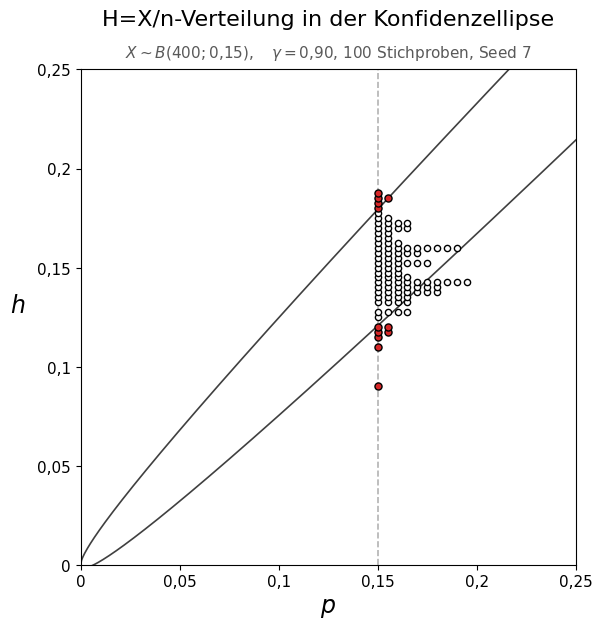

In [24]:
def number_token(value: float) -> str:
    text = f"{value:.6f}".rstrip("0").rstrip(".")
    return text.replace("-", "m").replace(".", "")


def figure_stem(cfg: Config) -> str:
    p0 = number_token(cfg.p0)
    gamma = number_token(cfg.gamma)
    return (
        f"Verfahrenswahrscheinlichkeit-n{cfg.n}-p{p0}-gamma{gamma}-"
        f"stichproben{cfg.number_of_samples}-seed{cfg.seed}"
    )


def save_figure(
    fig: plt.Figure,
    cfg: Config,
) -> tuple[Path, ...]:
    output_dir = Path(cfg.output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    stem = figure_stem(cfg)
    saved_files: list[Path] = []

    for raw_format in cfg.save_formats:
        file_format = raw_format.lower().lstrip(".")
        output_path = output_dir / f"{stem}.{file_format}"
        save_options: dict[str, object] = {"bbox_inches": "tight"}
        if file_format == "png":
            save_options["dpi"] = cfg.png_dpi
        fig.savefig(output_path, **save_options)
        saved_files.append(output_path)

    return tuple(saved_files)


def format_integer_ranges(values: np.ndarray) -> str:
    if values.size == 0:
        return "keine Trefferzahl"

    starts = [int(values[0])]
    ends: list[int] = []
    for previous, current in zip(values[:-1], values[1:]):
        if int(current) != int(previous) + 1:
            ends.append(int(previous))
            starts.append(int(current))
    ends.append(int(values[-1]))

    parts: list[str] = []
    for start, end in zip(starts, ends):
        if start == end:
            parts.append(f"X = {start}")
        else:
            parts.append(f"{start} <= X <= {end}")
    return " oder ".join(parts)


def print_results(
    cfg: Config,
    calculation: Calculation,
    saved_files: tuple[Path, ...],
) -> None:
    accepted = format_integer_ranges(calculation.accepted_x)
    inside_count = int(calculation.inside.sum())
    outside_count = cfg.number_of_samples - inside_count

    print(f"Binomialmodell: X ~ B({cfg.n}, {cfg.p0:g})")
    print(f"Zielniveau gamma = {cfg.gamma:g}")
    print(f"Prognoseintervall für H: [{calculation.prediction_lower_at_p0:.4f}; {calculation.prediction_upper_at_p0:.4f}]")
    print(f"Zugehörige Trefferzahlen: {accepted}")
    print(f"Modellwahrscheinlichkeit: {calculation.model_coverage:.4f}")
    print(
        f"Simulation: {inside_count} von {cfg.number_of_samples} innerhalb, "
        f"{outside_count} außerhalb"
    )
    print(f"Empirische Verfahrenswahrscheinlichkeit: {calculation.empirical_coverage:.4f}")
    for output_path in saved_files:
        print(f"Gespeichert: {output_path}")


def run(cfg: Config) -> tuple[Calculation, tuple[Path, ...]]:
    calculation = calculate(cfg)
    fig, _ = create_figure(cfg, calculation)

    saved_files: tuple[Path, ...] = ()
    if cfg.save_figure:
        saved_files = save_figure(fig, cfg)

    if cfg.show_text_output:
        print_results(cfg, calculation, saved_files)

    if cfg.show_figure:
        plt.show()
    else:
        plt.close(fig)

    return calculation, saved_files


calculation, saved_files = run(cfg)